In [10]:
# =====================导入依赖库=====================
import cv2
from skimage.util import random_noise
import numpy as np
from matplotlib import pyplot as plt

204 161 125


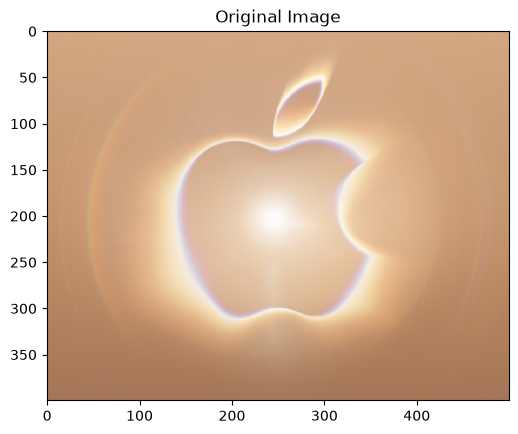

In [11]:
# ====================读取原始图像=====================
img = cv2.imread('p1.jpg')
# 获取图像中【100，100】这个像素的rbg三色
(b, g, r) = img[100, 100]
# 打印这个像素点的rbg参数
print(b, g, r)
# 输出原始图像
plt.imshow(img)
plt.title('Original Image')
plt.savefig('output_images/original_bgr.jpg', dpi=300)
plt.show()

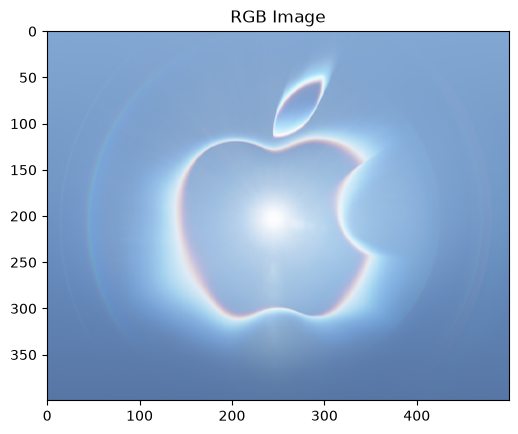

In [12]:
# 颜色空间转换，将原始图像BGR格式 转换成 RGB格式，蓝色和红色互换，因为把'B'和
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img)
plt.title('RGB Image')
plt.savefig('output_images/rgb_image.jpg', dpi=300)
plt.show()

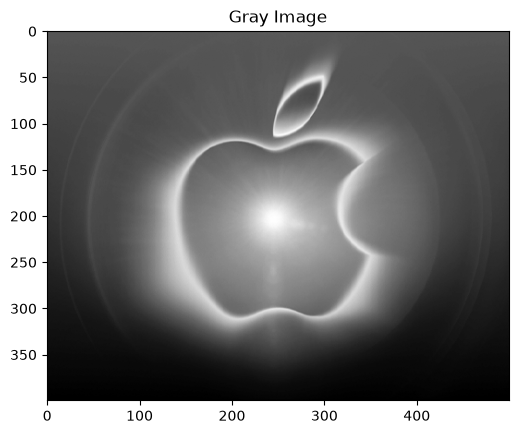

In [13]:
# 将原始图像的RBG格式转换为灰度图
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_img, cmap='gray')
plt.title('Gray Image')
plt.savefig('output_images/gray_image.jpg', dpi=300)
plt.show()

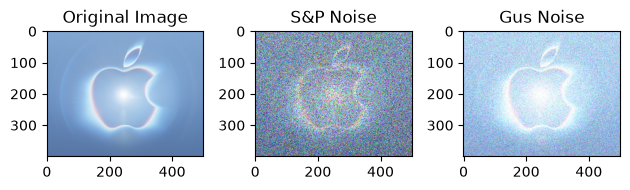

In [14]:
# ==========================添加噪声=========================
# mode='s&p'代表椒盐噪声，s代表白色，p代表黑色，amount=0.4代表会有40%的像素
sp_noise_img = random_noise(rgb_img, mode='s&p', amount=0.4)
# mode='gaussian' 代表高斯噪声，会在每个像素上添加随机偏差，服从高斯分布（均值
gus_noise_img = random_noise(rgb_img, mode='gaussian', mean=0.2, var=0.03)
# 原图
plt.subplot(1, 3, 1)
plt.imshow(rgb_img, cmap='gray')
plt.title('Original Image')
# 椒盐噪声
plt.subplot(1, 3, 2)
plt.imshow(sp_noise_img, cmap='gray')
plt.title('S&P Noise')
# 高斯噪声
plt.subplot(1, 3, 3)
plt.imshow(gus_noise_img, cmap='gray')
plt.title('Gus Noise')
plt.tight_layout()
plt.savefig('output_images/noise_comparison.jpg', dpi=300)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.39376494777132165..1.000000000000002].


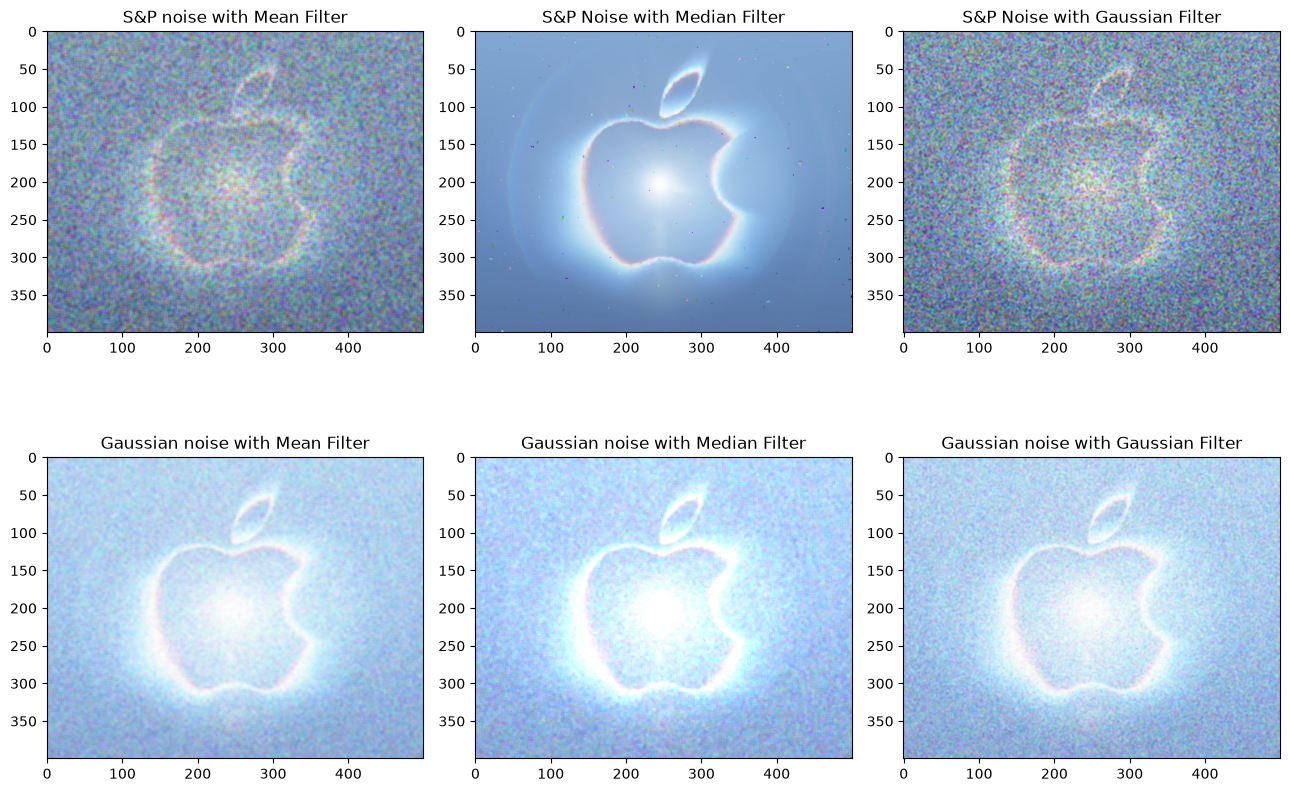

In [15]:
# =========================图像滤波=============================
# 均值滤波
mean_sp = cv2.blur(sp_noise_img, (5, 5))
mean_gus = cv2.blur(gus_noise_img, (5, 5))
# 中值滤波（需要 uint8）
mid_sp = cv2.medianBlur((sp_noise_img*255).astype(np.uint8), 5)
mid_gus = cv2.medianBlur((gus_noise_img*255).astype(np.uint8), 5)
# 高斯滤波
gauss_sp = cv2.GaussianBlur((sp_noise_img*255).astype(np.uint8), (5, 5), 0)
gauss_gus = cv2.GaussianBlur((gus_noise_img*255).astype(np.uint8), (5, 5), 0)
# 图像显示
plt.figure(figsize=(13, 9))
# 第1行：椒盐噪声
plt.subplot(2, 3, 1)
plt.imshow(mean_sp)
plt.title("S&P noise with Mean Filter")
plt.subplot(2, 3, 2)
plt.imshow(mid_sp)
plt.title("S&P Noise with Median Filter")
plt.subplot(2, 3, 3)
plt.imshow(gauss_sp)
plt.title("S&P Noise with Gaussian Filter")
# 第2行：高斯噪声
plt.subplot(2, 3, 4)
plt.imshow(mean_gus)
plt.title("Gaussian noise with Mean Filter")
plt.subplot(2, 3, 5)
plt.imshow(mid_gus)
plt.title("Gaussian noise with Median Filter")
plt.subplot(2, 3, 6)
plt.imshow(gauss_gus)
plt.title("Gaussian noise with Gaussian Filter")
plt.tight_layout()
plt.savefig('output_images/filter_results_2x3.jpg', dpi=300)
plt.show()

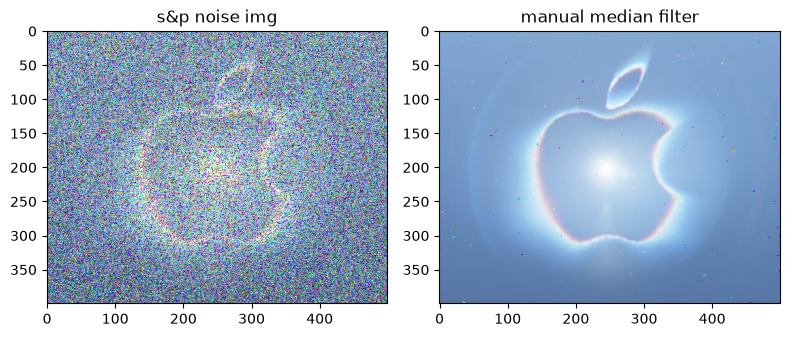

In [16]:
def manual_median_filter_color(image, kernel_size=5):
    pad = kernel_size // 2
    filtered_img = np.zeros_like(image)
    for c in range(3): 
        channel = image[:, :, c]
        padded_channel = np.pad(channel, pad_width=pad, mode='edge')
        for i in range(channel.shape[0]):
            for j in range(channel.shape[1]):
                region = padded_channel[i:i + kernel_size, j:j + kernel_size]
                filtered_img[i, j, c] = np.median(region)
    return filtered_img
    
manual_mid = manual_median_filter_color((sp_noise_img * 255).astype(np.uint8))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sp_noise_img, cmap='gray')
plt.title("s&p noise img")
plt.subplot(1, 2, 2)
plt.imshow(manual_mid, cmap='gray')
plt.title("manual median filter")
plt.tight_layout()
plt.savefig('output_images/manual_median.jpg', dpi=300)
plt.show()